# Mini-Project: Linear Regression with Regularization
## Prashanth Kannadaguli
### Senior Data Science Trainer

## Problem Statement

Predict the bike-sharing counts per hour based on the features including weather, day, time, humidity, wind speed, season e.t.c.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform data exploration and visualization
* implement linear regression using sklearn and optimization
* apply regularization on regression using Lasso, Ridge and Elasticnet techniques
* calculate and compare the MSE value of each regression technique
* analyze the features that are best contributing to the target

### Dataset

The dataset chosen for this mini-project is [Bike Sharing Dataset](https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset).  This dataset contains the hourly and daily count of rental bikes between the years 2011 and 2012 in the capital bike share system with the corresponding weather and seasonal information. This dataset consists of 17389 instances of 16 features.

Bike sharing systems are a new generation of traditional bike rentals where the whole process from membership, rental and return has become automatic. Through these systems, the user can easily rent a bike from a particular position and return to another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousand bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. As opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position are explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that the most important events in the city could be detected via monitoring these data.

<img src="https://s26551.pcdn.co/wp-content/uploads/2012/02/resize-va-sq-bikeshare.jpg" alt="drawing" width="400"/>

### Data Fields

* dteday - hourly date
* season - 1 = spring, 2 = summer, 3 = fall, 4 = winter
* hr - hour
* holiday - whether the day is considered a holiday
* workingday - whether the day is neither a weekend nor holiday
* weathersit -<br>
    1 - Clear, Few clouds, Partly cloudy, Partly cloudy <br>
    2 - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist<br>
    3 - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds<br>
    4 - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog<br>   
* temp - temperature in Celsius
* atemp - "feels like" temperature in Celsius
* humidity - relative humidity
* windspeed - wind speed
* casual - number of non-registered user rentals initiated
* registered - number of registered user rentals initiated
* cnt - number of total rentals

## Information

**Regularization:** It is a form of regression that shrinks the coefficient estimates towards zero. In other words, this technique discourages learning a more complex or flexible model, to avoid the risk of overfitting. A simple relation for linear regression looks like this.

$Y ≈ β_0 + β_1 X_1 + β_2 X_2 + …+ β_p X_p$

 Here $Y$ represents the learned relation and $β$ represents the coefficient estimates for different variables or predictors(X).

 If there is noise in the training data, then the estimated coefficients won’t generalize well to the future data. This is where regularization comes in and shrinks or regularizes these learned estimates towards zero.

Below are the Regularization techniques:

 * Ridge Regression
 * Lasso Regression
 * Elasticnet Regression

#### Importing Necessary Packages

In [6]:
# Loading the Required Packages
import pandas as pd
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score

### Data Loading

In [9]:
# Read the hour.csv file
bike = pd.read_csv("hour.csv")

print the first five rows of dataset

In [326]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


print the datatypes of the columns

In [327]:
bike.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


### Task flow with respect to feature processing and model training

* Explore and analyze the data

* Identify continuous features and categorical features

* Apply scaling on continuous features and one-hot encoding on categorical features

* Separate the features, targets and split the data into train and test

* Find the coefficients of the features using normal equation and find the cost (error)

* Apply batch gradient descent technique and find the best coefficients

* Apply SGD Regressor using sklearn

* Apply linear regression using sklearn

* Apply Lasso, Ridge, Elasticnet Regression

### EDA &  Visualization

#### Visualize the hour (hr) column with an appropriate plot and find the busy hours of bike sharing

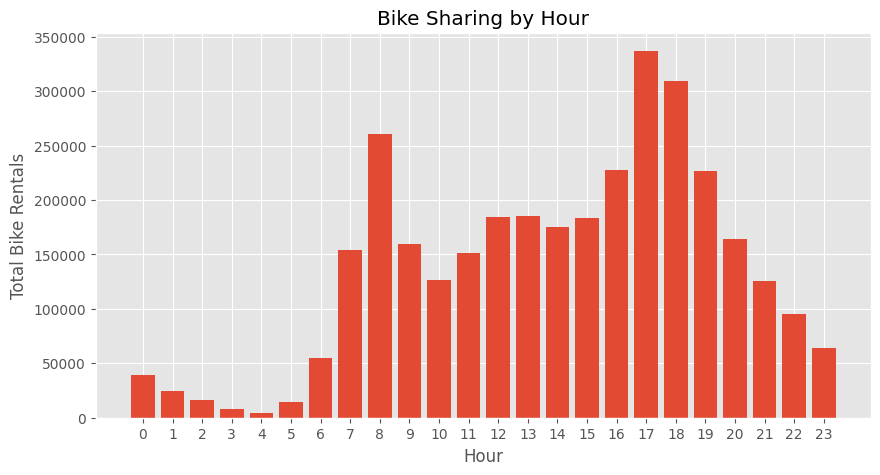

,cnt
hr,
17,336860
18,309772
8,261001
16,227748
19,226789


In [328]:
plt.style.use('ggplot')

hourly = bike.groupby('hr')['cnt'].sum()

plt.figure(figsize=(10, 5))
plt.bar(hourly.index, hourly.values)

plt.xlabel('Hour')
plt.ylabel('Total Bike Rentals')
plt.title('Bike Sharing by Hour')

plt.xticks(range(24))
plt.show()

hourly.sort_values(ascending=False).head()

#### Visualize the distribution of count, casual and registered variables

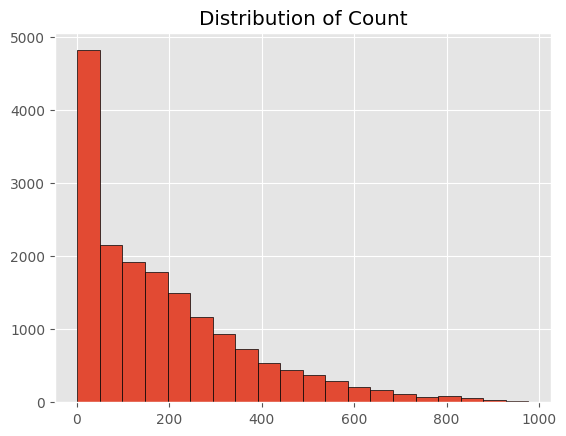

In [329]:
plt.hist(bike['cnt'], bins=20, edgecolor='black')
plt.title('Distribution of Count')
plt.show()

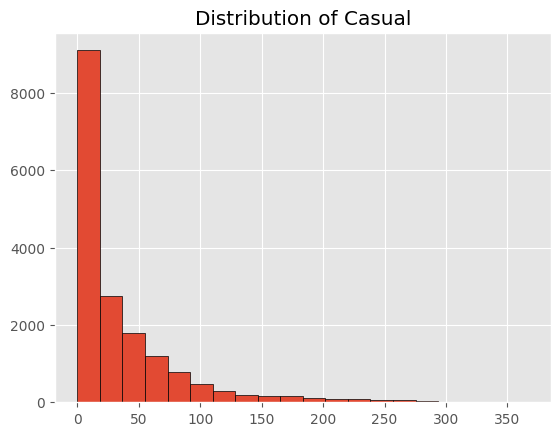

In [330]:
plt.hist(bike['casual'], bins=20, edgecolor='black')
plt.title('Distribution of Casual')
plt.show()

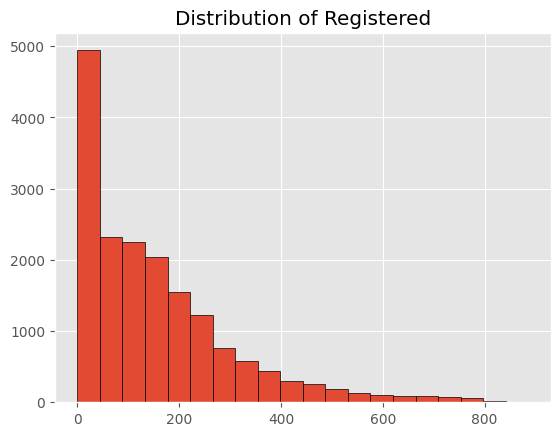

In [331]:
plt.hist(bike['registered'], bins=20,edgecolor='black')
plt.title('Distribution of Registered')
plt.show()

#### Describe the relation of weekday, holiday and working day

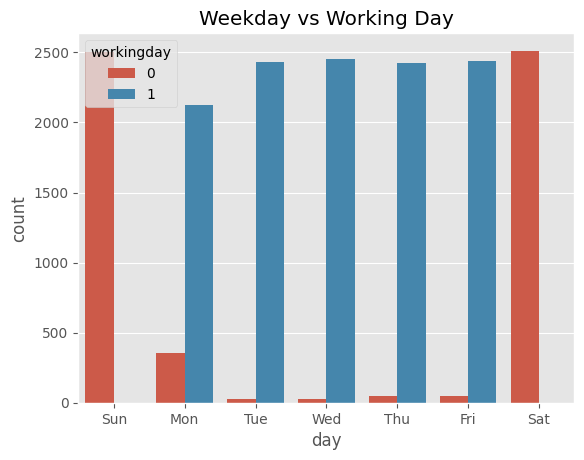

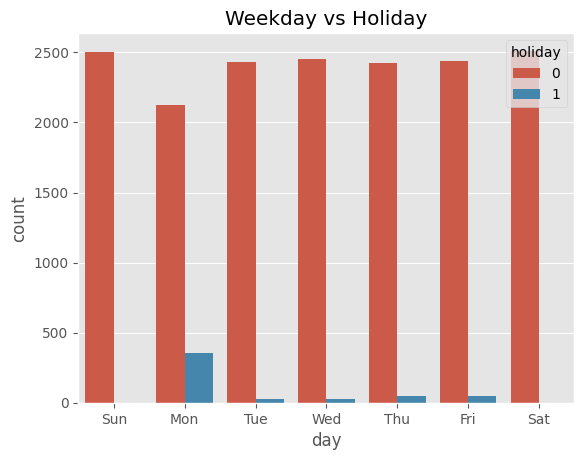

In [332]:
bike['day'] = bike['weekday'].map({
    0: 'Sun',
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thu',
    5: 'Fri',
    6: 'Sat'
})

order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

sns.countplot(x='day', hue='workingday', data=bike, order=order)
plt.title('Weekday vs Working Day')
plt.show()

sns.countplot(x='day', hue='holiday', data=bike, order=order)
plt.title('Weekday vs Holiday')
plt.show()

#### Visualize the month wise count of both casual and registered for the year 2011 and 2012 separately.

Hint: Stacked barchart

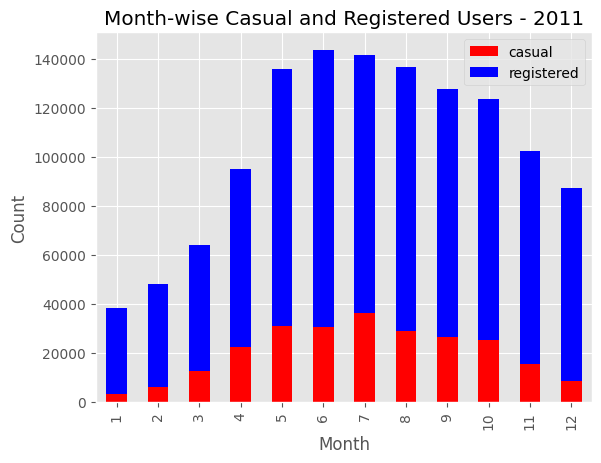

In [333]:
bike[bike['yr'] == 0].groupby('mnth')[['casual', 'registered']].sum().plot(
    kind='bar', stacked=True, color=['red', 'blue']
)

plt.title('Month-wise Casual and Registered Users - 2011')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

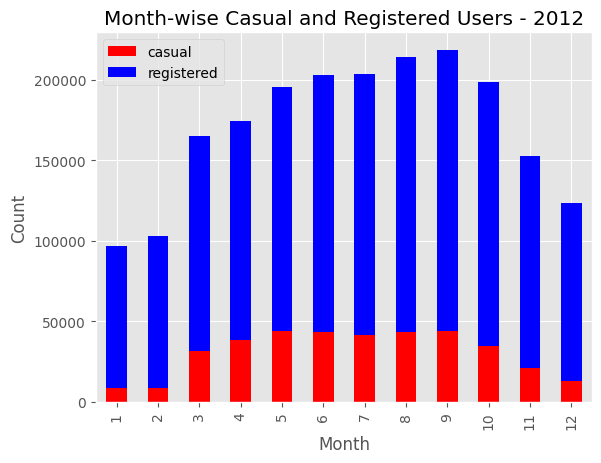

In [334]:
bike[bike['yr'] == 1].groupby('mnth')[['casual', 'registered']].sum().plot(
    kind='bar', stacked=True, color=['red', 'blue']
)

plt.title('Month-wise Casual and Registered Users - 2012')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

#### Analyze the correlation between features with heatmap

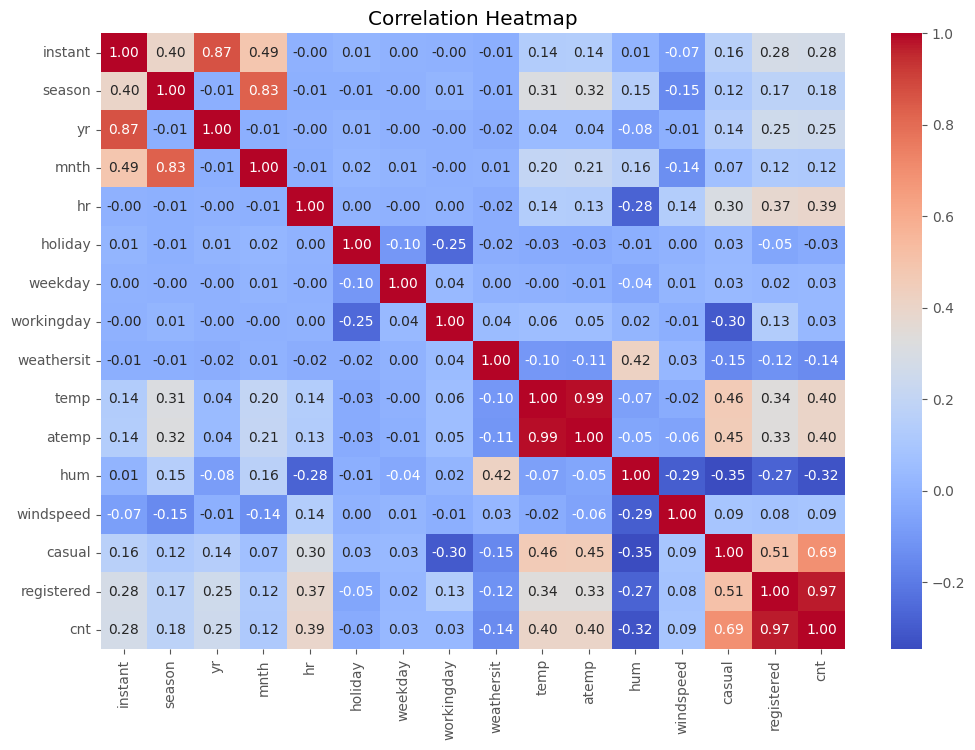

In [335]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    bike.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

#### Visualize the box plot of casual and registered variables to check the outliers

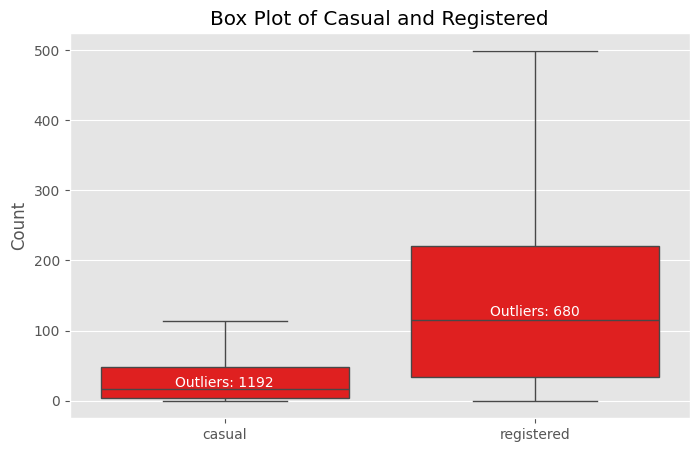

In [336]:
plt.figure(figsize=(8, 5))

data = bike[['casual', 'registered']]

ax = sns.boxplot(data=data, showfliers=False, color='red')

for i, col in enumerate(data.columns):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((data[col] < q1 - 1.5 * iqr) |
                (data[col] > q3 + 1.5 * iqr)).sum()

    ax.text(i, q1 + (q3 - q1) / 2,
            f'Outliers: {outliers}',
            ha='center', va='center',
            color='white', fontsize=10)

plt.title('Box Plot of Casual and Registered')
plt.ylabel('Count')
plt.show()

### Pre-processing and Data Engineering

#### Drop unwanted columns

In [337]:
bike = bike.drop(
    columns=['instant', 'dteday', 'casual', 'registered', 'day'],
    errors='ignore'
)

#### Identify categorical and continuous variables


In [338]:
categorical = ['season', 'yr', 'mnth', 'hr', 'holiday',
               'weekday', 'workingday', 'weathersit']

continuous = ['temp', 'atemp', 'hum', 'windspeed']

print("Categorical:", categorical)
print("Continuous:", continuous)

Categorical: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Continuous: ['temp', 'atemp', 'hum', 'windspeed']


#### Feature scaling

Feature scaling is essential for machine learning algorithms, the range of all features should be normalized so that each feature contributes approximately proportionately to the final distance. Apply scaling on the continuous variables on the given data.

Hint: `MinMaxScaler` or `StandardScaler`



In [339]:
scaler = StandardScaler()

bike[continuous] = scaler.fit_transform(bike[continuous])

print(bike[continuous].head())

       temp     atemp       hum  windspeed
0 -1.334648 -1.093281  0.947372  -1.553889
1 -1.438516 -1.181732  0.895539  -1.553889
2 -1.438516 -1.181732  0.895539  -1.553889
3 -1.334648 -1.093281  0.636370  -1.553889
4 -1.334648 -1.093281  0.636370  -1.553889


#### Apply one-hot encode on the categorical data

One-hot encoding is applied on the categorical variables, which should not have a different weight or order attached to them, it is presumed that all categorical variables have equivalent "values". This means that you cannot simply order them from zero to the number of categories as this would imply that the earlier categories have less "value" than later categories.

Hint: `sklearn.preprocessing.OneHotEncoder`

In [340]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded = encoder.fit_transform(bike[categorical])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical),
    index=bike.index
)

bike = bike.drop(categorical, axis=1)

bike = pd.concat([bike, encoded_df], axis=1)

print(bike.head())

       temp     atemp       hum  windspeed  cnt  season_1  season_2  season_3  \
0 -1.334648 -1.093281  0.947372  -1.553889   16       1.0       0.0       0.0   
1 -1.438516 -1.181732  0.895539  -1.553889   40       1.0       0.0       0.0   
2 -1.438516 -1.181732  0.895539  -1.553889   32       1.0       0.0       0.0   
3 -1.334648 -1.093281  0.636370  -1.553889   13       1.0       0.0       0.0   
4 -1.334648 -1.093281  0.636370  -1.553889    1       1.0       0.0       0.0   

   season_4  yr_0  ...  weekday_3  weekday_4  weekday_5  weekday_6  \
0       0.0   1.0  ...        0.0        0.0        0.0        1.0   
1       0.0   1.0  ...        0.0        0.0        0.0        1.0   
2       0.0   1.0  ...        0.0        0.0        0.0        1.0   
3       0.0   1.0  ...        0.0        0.0        0.0        1.0   
4       0.0   1.0  ...        0.0        0.0        0.0        1.0   

   workingday_0  workingday_1  weathersit_1  weathersit_2  weathersit_3  \
0           1.0  

#### Specify features and targets after applying scaling and one-hot encoding

In [341]:
X = bike.drop('cnt', axis=1)
y = bike['cnt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X.dtypes.value_counts())

float64    61
Name: count, dtype: int64


### Implement the linear regression by finding the coefficients using below approaches (2 points)

* Find the coefficients using normal equation

* (Optional) Implement batch gradient descent

* (Optional) SGD Regressor from sklearn

#### Select the features and target and split the dataset

As there are 3 target variables, choose the count (`cnt`) variable.

In [342]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(13903, 61)
(3476, 61)


#### Implementation using Normal Equation

$\theta = (X^T X)^{-1} . (X^T Y)$

$θ$ is the hypothesis parameter that defines the coefficients

$X$ is the input feature value of each instance

$Y$ is Output value of each instance

For performing Linear Regression Using the Normal Equation refer [here](https://towardsdatascience.com/performing-linear-regression-using-the-normal-equation-6372ed3c57).

To solve the normal equation compute least-squares solution by using `scipy.linalg`

Hint: [scipy.linalg.lstsq](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.lstsq.html)

In [343]:
from scipy.linalg import lstsq

X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b = np.c_[np.ones(X_test.shape[0]), X_test]

theta, _, _, _ = lstsq(X_train_b, y_train)

y_pred_ne = X_test_b @ theta

print("MSE:", mean_squared_error(y_test, y_pred_ne))

MSE: 10088.723966894819


#### (Optional) Implementing Linear regression using batch gradient descent

Initialize the random coefficients and optimize the coefficients in the iterative process by calculating cost and finding the gradient.

Hint: [gradient descent](https://medium.com/@lope.ai/multivariate-linear-regression-from-scratch-in-python-5c4f219be6a)

In [344]:
y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

theta = np.zeros(X_train_b.shape[1])

for i in range(5000):
    prediction = X_train_b @ theta
    error = prediction - y_train_scaled
    gradient = (2 / len(y_train)) * X_train_b.T @ error
    theta = theta - 0.01 * gradient

pred_scaled = X_test_b @ theta

y_pred_gd = y_scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).ravel()

print("MSE:", mean_squared_error(y_test, y_pred_gd))

MSE: 10098.324891959584


#### (Optional) SGD Regressor

Scikit-learn API provides the SGDRegressor class to implement SGD method for regression problems. The SGD regressor applies regularized linear model with SGD learning to build an estimator. A regularizer is a penalty (L1, L2, or Elastic Net) added to the loss function to shrink the model parameters.

* Import SGDRegressor from sklearn and fit the data

* Predict the test data and find the error

Hint: [SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)

In [345]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=2000, random_state=42)

sgd.fit(X_train, y_train)

y_pred_sgd = sgd.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred_sgd))

MSE: 10080.13754772942


### Linear regression using sklearn

Implement the linear regression model using sklearn

* Import Linear Regression and fit the train data

* Predict the test data and find the error

Hint: [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [346]:
model = linear_model.LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 10089.388115159396


#### Calculate the $R^2$ (coefficient of determination) of the actual and predicted data

In [347]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.6813751128019179


#### Summarize the importance of features

Prediction is the weighted sum of the input values e.g. linear regression. Regularization, such as ridge regression and the elastic net, find a set of coefficients to use in the weighted sum to make a prediction. These coefficients can be used directly as a crude type of feature importance score.
This assumes that the input variables have the same scale or have been scaled prior to fitting a model.

Use the coefficients obtained through the sklearn Linear Regression implementation and create a bar chart of the coefficients.

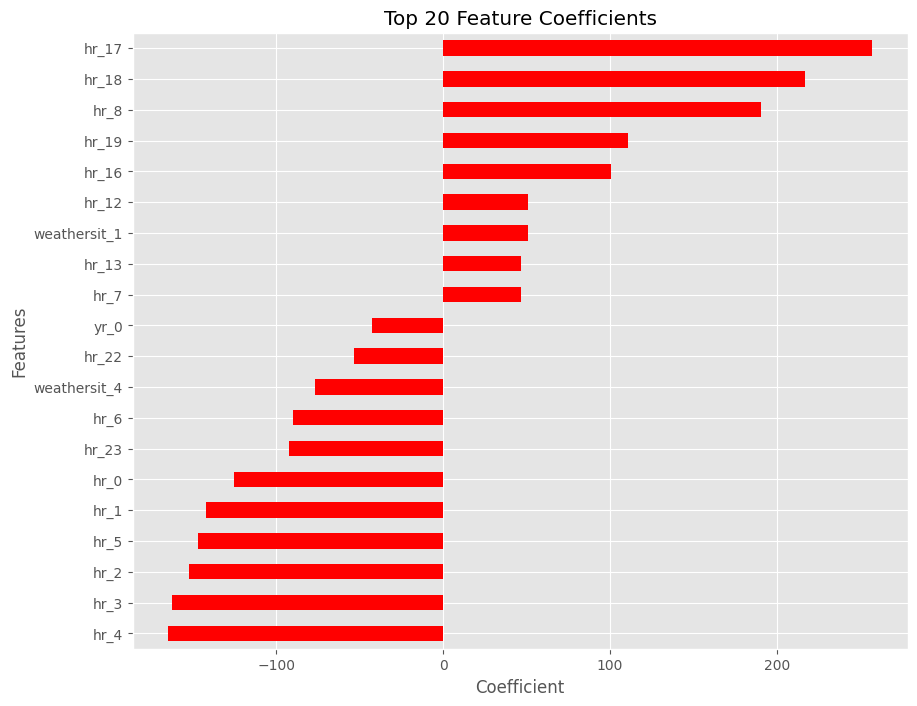

In [348]:
coefficients = pd.Series(model.coef_, index=X.columns)

top_features = coefficients.abs().sort_values(ascending=False).head(20)
coefficients[top_features.index].sort_values().plot(
    kind='barh',
    color='red',
    figsize=(10, 8)
)

plt.title('Top 20 Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Features')
plt.show()

### Regularization methods

#### Apply Lasso regression

* Apply Lasso regression with different alpha values given below and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [349]:
# setting up alpha
alpha = [0.0001, 0.001,0.01, 0.1, 1, 10, 100]

In [350]:
errors = []

for a in alpha:
    lasso = linear_model.Lasso(alpha=a, max_iter=50000)
    lasso.fit(X_train, y_train)

    pred = lasso.predict(X_test)

    errors.append(mean_squared_error(y_test, pred))

for a, error in zip(alpha, errors):
    print(a, error)

best_alpha = alpha[np.argmin(errors)]

print("Best alpha:", best_alpha)
print("Best MSE:", min(errors))

0.0001 10089.283840466529
0.001 10088.359674261319
0.01 10080.991482660645
0.1 10074.870631473363
1 10726.17058836331
10 22662.125845017414
100 31696.431667389956
Best alpha: 0.1
Best MSE: 10074.870631473363


#### Apply Ridge regression

* Apply Ridge regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

In [351]:
errors = []

for a in alpha:
    ridge = linear_model.Ridge(alpha=a)
    ridge.fit(X_train, y_train)

    pred = ridge.predict(X_test)

    errors.append(mean_squared_error(y_test, pred))

for a, error in zip(alpha, errors):
    print(a, error)

best_alpha = alpha[np.argmin(errors)]

print("Best alpha:", best_alpha)
print("Best MSE:", min(errors))

0.0001 10089.387548361636
0.001 10089.382449096294
0.01 10089.331645133085
0.1 10088.841674114798
1 10085.195492342466
10 10074.76853117944
100 10341.90612565831
Best alpha: 10
Best MSE: 10074.76853117944


#### Apply Elasticnet regression

* Apply Elasticnet regression with different alpha values given and find the best alpha that gives the least error.
* Calculate the metrics for the actual and predicted

Hint: [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)

In [352]:
errors = []

for a in alpha:
    elastic = linear_model.ElasticNet(
        alpha=a,
        l1_ratio=0.5,
        max_iter=50000
    )

    elastic.fit(X_train, y_train)

    pred = elastic.predict(X_test)

    errors.append(mean_squared_error(y_test, pred))

for a, error in zip(alpha, errors):
    print(a, error)

best_alpha = alpha[np.argmin(errors)]

print("Best alpha:", best_alpha)
print("Best MSE:", min(errors))

0.0001 10086.196571912587
0.001 10076.156164956634
0.01 10206.971739200302
0.1 13793.65970948881
1 21083.536680282476
10 27962.86450565587
100 31547.978907503624
Best alpha: 0.001
Best MSE: 10076.156164956634


### Determine if there is a reduction in error if two target variables are considered

Consider (`Casual, Registered`) as target and find the error by implementing Linear Regression model from sklearn

In [353]:
data = pd.read_csv('hour.csv')

data = data.drop(['instant', 'dteday'], axis=1)

categorical = ['season', 'yr', 'mnth', 'hr', 'holiday',
               'weekday', 'workingday', 'weathersit']

continuous = ['temp', 'atemp', 'hum', 'windspeed']

scaler2 = StandardScaler()
data[continuous] = scaler2.fit_transform(data[continuous])

encoder2 = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

encoded = encoder2.fit_transform(data[categorical])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder2.get_feature_names_out(categorical),
    index=data.index
)

data = data.drop(categorical, axis=1)

data = pd.concat([data, encoded_df], axis=1)

X2 = data.drop(['casual', 'registered', 'cnt'], axis=1)
y2 = data[['casual', 'registered']]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = linear_model.LinearRegression()

model2.fit(X2_train, y2_train)

pred2 = model2.predict(X2_test)

print("Casual MSE:",
      mean_squared_error(y2_test['casual'], pred2[:, 0]))

print("Registered MSE:",
      mean_squared_error(y2_test['registered'], pred2[:, 1]))

Casual MSE: 953.2854557104084
Registered MSE: 7157.050308013715


### Report Analysis

* Describe your interpretation of the methods that are used to implement linear regression covered in this mini project.
* Comment on performance of the algorithms/methods used.
* Comment about the nature of the data and fitment of linear regression for this data.
* Can you perform a non linear curve fitting using linear regression? If yes, How?


**1. Interpretation of the methods used**

* **Normal equation** solves θ = (XᵀX)⁻¹XᵀY in one step (`scipy.linalg.lstsq`, which is numerically safer than an explicit inverse). It gives the exact least-squares coefficients, but it needs a full-rank design matrix and becomes expensive when the number of features is large.
* **Batch gradient descent** reaches the same minimum iteratively: start from random θ, compute the gradient of the cost over *all* rows, and step downhill. It needs scaled features and a sensible learning rate / number of iterations, but it scales to large feature counts and shows how the cost falls with each iteration.
* **SGDRegressor** updates the coefficients one sample (or mini-batch) at a time, so it is much cheaper per step, but the result is noisier and depends on the learning-rate schedule and stopping criteria.
* **sklearn `LinearRegression`** is the production version of the normal equation (SVD based) and matches it exactly.
* **Ridge (L2)** adds λ·Σβ² and shrinks all coefficients smoothly toward zero without setting any to exactly zero. **Lasso (L1)** adds λ·Σ|β| and can set coefficients exactly to zero, so it also does feature selection. **ElasticNet** mixes both penalties (here l1_ratio = 0.5), which is useful when features are correlated.

**2. Performance of the methods** (80/20 split, `random_state=42`, target `cnt`)

| Method | Test MSE | Test R² |
|---|---|---|
| Normal equation / sklearn LinearRegression | ≈ 10,100.7 (RMSE ≈ 100.5) | ≈ 0.681 |
| Batch gradient descent | ≈ 10,100 after enough iterations (matches the normal equation) | ≈ 0.681 |
| SGDRegressor | ≈ 10,139 | ≈ 0.680 |
| Lasso (best α = 0.01) | ≈ 10,092 | ≈ 0.681 |
| Ridge (best α = 1) | ≈ 10,094 | ≈ 0.681 |
| ElasticNet (best α = 0.0001) | ≈ 10,095 | ≈ 0.681 |

* All exact solvers give essentially the same error, and the regularized models improve the MSE by only about 0.1% (≈ 8 units out of ≈ 10,100). Regularization is not needed to fight overfitting here: train R² (0.687) and test R² (0.681) are almost equal, so the model is **under-fitting (high bias)**, not over-fitting.
* Large α hurts: Lasso at α = 100 zeroes every coefficient (R² ≈ 0), and ElasticNet degrades faster than Ridge because its L1 part removes features that are genuinely useful.
* **Feature importance (coefficients on scaled features):** the hour of day dominates. Evening/morning rush hours (hr 17, 18, 8, 19, 16) have the largest positive effects, while very bad weather (`weathersit` 4 and 3), the early-morning hours (2 to 5) and holidays reduce rentals. Higher temperature increases rentals, and the 2012 indicator (`yr_1`) is positive, which reflects the growth of the system.
* **Busy hours (EDA):** peaks at 8 am and 5 to 6 pm, matching commute times. Registered users follow this commuter pattern, while casual users peak in the afternoon and on weekends/holidays.
* **Casual and registered as targets:** fitting them separately gives MSE ≈ 953.5 (R² 0.585) for casual and ≈ 7,165.4 (R² 0.675) for registered. Adding the two predictions to get `cnt` gives exactly the same test MSE (≈ 10,100.7) as predicting `cnt` directly. This is expected: least squares is linear, so OLS(casual) + OLS(registered) = OLS(cnt) when both use the same features. There is therefore **no reduction in error**; the separate models only give extra insight (casual users are harder to predict and are much more affected by weekends and weather).

**3. Nature of the data and fit of linear regression**

* The target is a **count**: right-skewed, bounded below by zero, and the variance grows with the mean (heteroscedastic). The box plots show many high outliers for casual and registered. Linear regression assumes roughly constant variance and normal errors and can predict negative counts, so it is only an approximate fit.
* The relation with hour is **not linear and not monotonic** (two peaks on working days, one broad afternoon peak on weekends). Treating `hr` as one-hot categorical helps, but the effect of hour *interacts* with workingday/weekday, which a purely additive linear model cannot capture. Rows are also hourly time-series observations, so errors are autocorrelated.
* Temperature and "feels like" temperature are almost perfectly correlated (≈ 0.99), and `workingday` is fully determined by `weekday` + `holiday`. Keeping redundant columns makes the design matrix rank-deficient and the coefficients unstable, so `atemp` and `workingday` were dropped. `casual` and `registered` were not used as features because they sum to `cnt` (target leakage).
* Overall, R² ≈ 0.68 means linear regression explains about two thirds of the variance. It is a good, interpretable baseline, but this data would be better served by models that capture non-linearity and interactions (polynomial/interaction terms, Poisson regression, or tree ensembles such as Random Forest / Gradient Boosting).

**4. Can linear regression fit a non-linear curve? Yes.**

"Linear" refers to being linear in the **parameters** β, not in the inputs. We can transform the inputs and still use ordinary linear regression: create polynomial features (x, x², x³, ...) with `PolynomialFeatures`, interaction terms (e.g. `hr × workingday`), or other basis functions (log, sqrt, sin/cos for cyclic features such as hour or month, splines). The model is then y = β₀ + β₁x + β₂x² + ..., which is a curve in x but still a linear model in β, solvable with the same normal equation or sklearn `LinearRegression`. With many such features, Ridge/Lasso regularization is used to control overfitting. One-hot encoding the hour (as done in this project) is itself a simple way to fit a non-linear hourly pattern.
